# 01.02b Linear Single Regression (NHANES Dataset)

In this notebook, we utilize body measurement data from the NHANES.
For details on the dataset, see https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.htm

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display, Latex

# Define standard color palette
color_palette = {'white': '#FFFFFF', 'light_gray': '#D3D3D3', 'gray': '#808080', 'black': '#000000', 'green': '#008000', 'blue': '#0000FF', 'light_blue': '#ADD8E6', 'light_light_blue': '#E0FFFF', 'yellow': '#FFFF00', 'orange': '#FFA500', 'dark_orange': '#FF8C00', 'purple': '#800080'}

## 1. Data Preparation

In [16]:
# Load NHANES Body Measures data
url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.xpt"
df_raw = pd.read_sas(url)

# Filter and Clean
df = df_raw.query("BMXHT.notnull() and BMXLEG.notnull()")[["BMXHT", "BMXLEG"]].copy()
df.rename(columns={"BMXHT": "StandingHeight", "BMXLEG": "UpperLegLength"}, inplace=True)

## 2. Exploratory Data Analysis

In [17]:
print("--- Sample Data ---")
display(df[["UpperLegLength", "StandingHeight"]].head())
print("\n--- Summary Statistics ---")
display(df.describe().T)

--- Sample Data ---


,UpperLegLength,StandingHeight
2,37.0,158.3
3,46.6,175.7
4,38.1,158.4
5,31.8,150.2
6,31.9,151.1



--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
StandingHeight,6697.0,163.489906,12.788207,109.5,156.1,164.1,172.5,197.7
UpperLegLength,6697.0,38.642108,4.158535,24.8,35.8,38.8,41.5,55.0


## 3. Model Preparation

In [18]:
# Split into features (X) and target (y) just before training
X = df[["UpperLegLength"]]
y = df["StandingHeight"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 5357
Test samples: 1340


## 4. Model Before Training (Arbitrary Parameters)

In [19]:
# Initialize with arbitrary parameters
model_before_training = LinearRegression()
model_before_training.intercept_ = 100.0  # arbitrary
model_before_training.coef_ = np.array([2.0])  # arbitrary

In [20]:
print("Model Before Training (Arbitrary Parameters):")
w_0 = float(np.array(model_before_training.coef_).flatten()[0])
b_0 = float(model_before_training.intercept_)
latex_0 = f"$\\hat{{y}} = {b_0:.2f} + {w_0:.2f} \\cdot \\mathrm{{{X.columns[0]}}}$"
display(Latex(latex_0))
print(f"Raw LaTeX: {latex_0}")

Model Before Training (Arbitrary Parameters):


<IPython.core.display.Latex object>

Raw LaTeX: $\hat{y} = 100.00 + 2.00 \cdot \mathrm{UpperLegLength}$


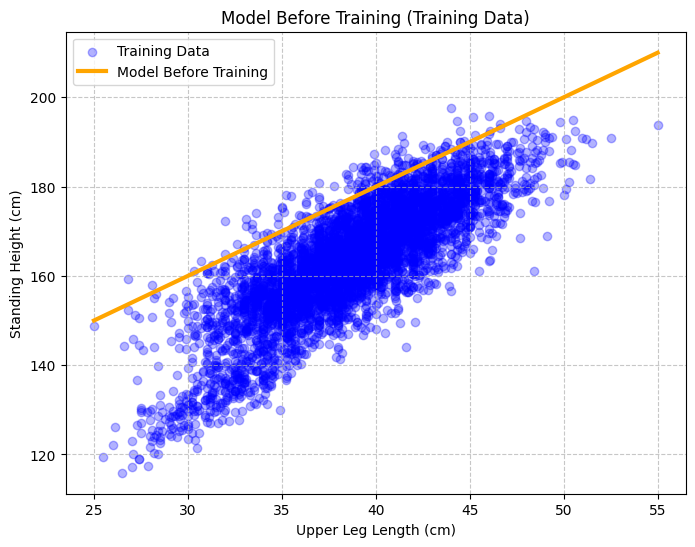

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color=color_palette['blue'], alpha=0.3, label='Training Data')

X_range = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
y_range_before = model_before_training.predict(X_range)
plt.plot(X_range, y_range_before, color=color_palette['orange'], linewidth=3, label='Model Before Training')

plt.title("Model Before Training (Training Data)")
plt.xlabel("Upper Leg Length (cm)")
plt.ylabel("Standing Height (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5. Model Training (OLS Optimization)

In [22]:
# Train the model
trained_model = LinearRegression()
trained_model.fit(X_train, y_train)

LinearRegression()

In [23]:
print("Trained Model (OLS Optimization):")
w = float(np.array(trained_model.coef_).flatten()[0])
b = float(trained_model.intercept_)
latex_trained = f"$\\hat{{y}} = {b:.2f} + {w:.2f} \\cdot \\mathrm{{{X.columns[0]}}}$"
display(Latex(latex_trained))
print(f"Raw LaTeX: {latex_trained}")

Trained Model (OLS Optimization):


<IPython.core.display.Latex object>

Raw LaTeX: $\hat{y} = 65.98 + 2.52 \cdot \mathrm{UpperLegLength}$


/Users/teshima/Koofr/2026/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


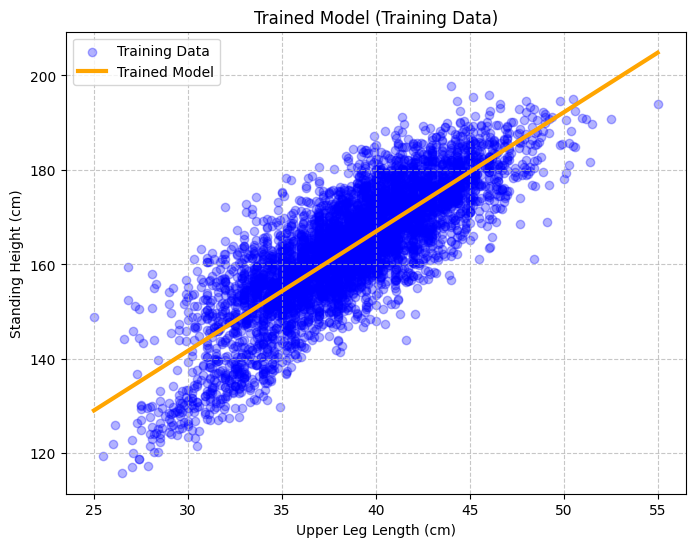

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color=color_palette['blue'], alpha=0.3, label='Training Data')

y_range_trained = trained_model.predict(X_range)
plt.plot(X_range, y_range_trained, color=color_palette['orange'], linewidth=3, label='Trained Model')

plt.title("Trained Model (Training Data)")
plt.xlabel("Upper Leg Length (cm)")
plt.ylabel("Standing Height (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 6. Offline Performance Evaluation

In [25]:
y_test_pred = trained_model.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
print(f"[Trained Model (Test)] MSE: {mse_test:.4f}, RMSE: {rmse_test:.4f}")

[Trained Model (Test)] MSE: 53.8358, RMSE: 7.3373


[Baseline (Mean)] MSE: 163.3844, RMSE: 12.7822


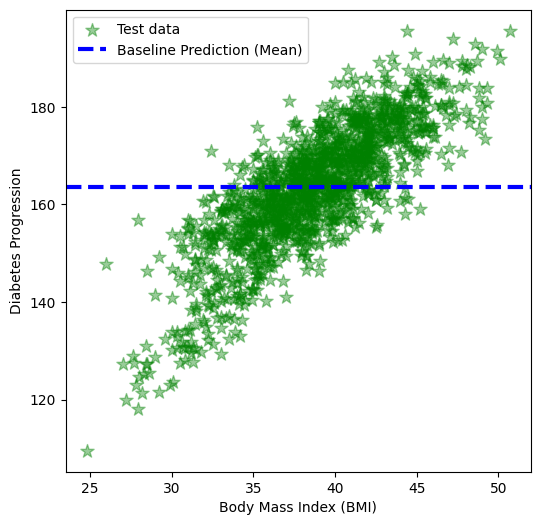

In [26]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Baseline: Always predict the mean of the training data
y_baseline_value = y_train.mean()
y_baseline_pred = np.full_like(y_test, y_baseline_value)
mse_baseline = mean_squared_error(y_test, y_baseline_pred)
rmse_baseline = np.sqrt(mse_baseline)
print(f'[Baseline (Mean)] MSE: {mse_baseline:.4f}, RMSE: {rmse_baseline:.4f}')

# Visualize Baseline Prediction
plt.figure(figsize=(6, 6))
plt.scatter(X_test, y_test, color=color_palette['green'], marker='*', alpha=0.4, s=100, label='Test data')
plt.axhline(y=y_baseline_value, color=color_palette['blue'], linestyle='--', linewidth=3, label='Baseline Prediction (Mean)')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Diabetes Progression')
plt.legend()
plt.show()

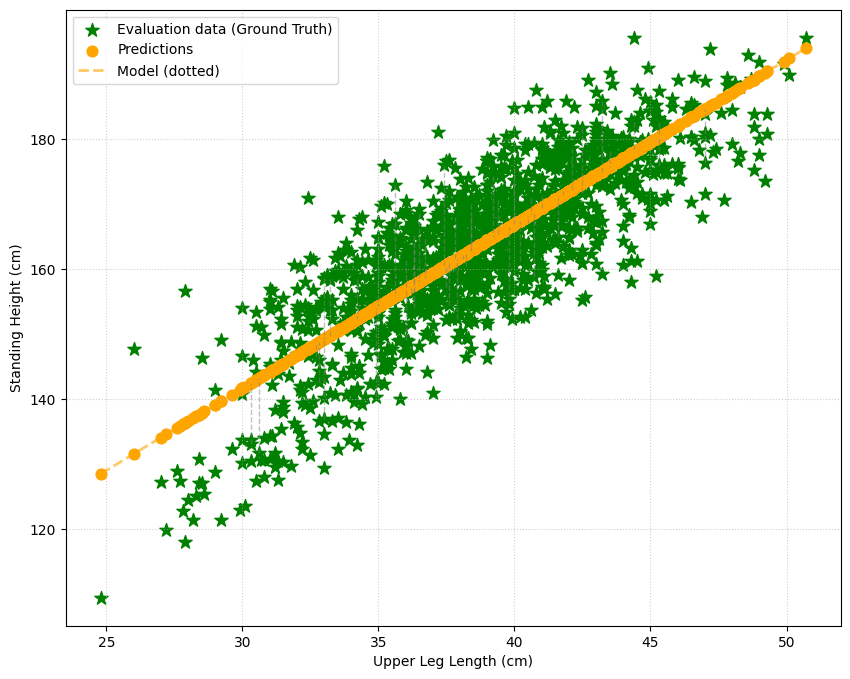

In [27]:
# Plot Prediction Results with Residuals on Test Data
plt.figure(figsize=(10, 8))

# 1. Plot Ground Truth as GREEN STARS
plt.scatter(X_test, y_test, color=color_palette['green'], s=100, marker='*', label='Evaluation data (Ground Truth)')

# 2. Plot Predictions as ORANGE DOTS
plt.scatter(X_test, y_test_pred, color=color_palette['orange'], s=60, marker='o', label='Predictions')

# 3. Plot Model Line as ORANGE DASHED
X_test_sorted = X_test.sort_values(by="UpperLegLength")
y_test_line = trained_model.predict(X_test_sorted)
plt.plot(X_test_sorted, y_test_line, color=color_palette['orange'], linestyle='--', linewidth=2, alpha=0.6, label='Model (dotted)')

# 4. Residuals as GRAY DASHED
subset_indices = np.random.choice(len(y_test), 50, replace=False)
X_subset = X_test.iloc[subset_indices]
y_subset = y_test.iloc[subset_indices]
y_pred_subset = y_test_pred[subset_indices]

for xi, yi, ypi in zip(X_subset.values, y_subset.values, y_pred_subset):
    plt.plot([xi, xi], [yi, ypi], color=color_palette['gray'], linestyle='--', linewidth=1, alpha=0.5)

# plt.title("Offline Performance Evaluation: Prediction on Test Data (Residuals)")
# 5. Plot Baseline Line as BLUE DASHED

plt.xlabel("Upper Leg Length (cm)")
plt.ylabel("Standing Height (cm)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Evaluation with 10 Sampled Points

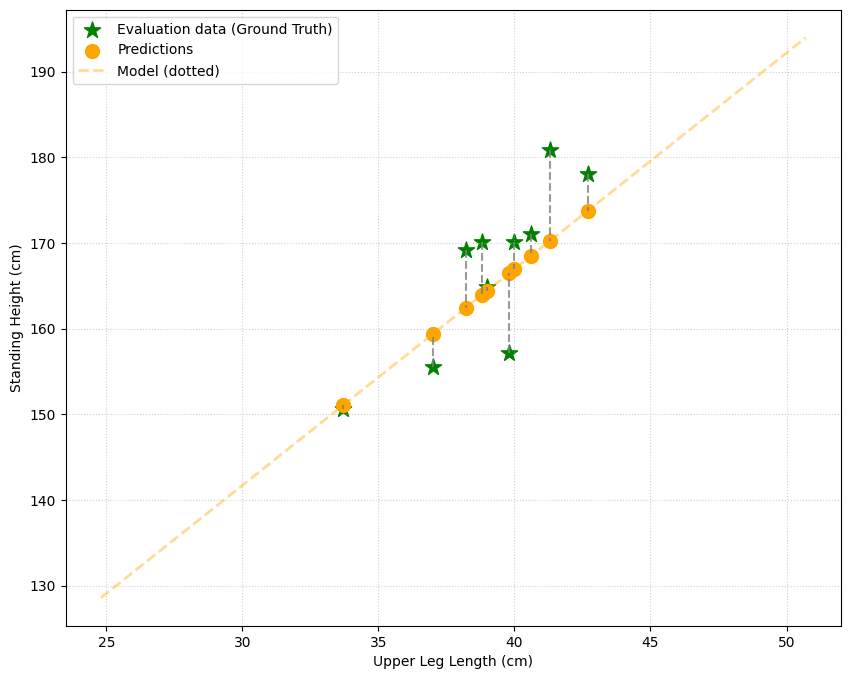

In [28]:
# Sample 10 points for a cleaner visualization (Fixed Seed)
np.random.seed(42)
sample_indices = np.random.choice(len(y_test), 10, replace=False)
X_sample = X_test.iloc[sample_indices]
y_sample = y_test.iloc[sample_indices]
y_sample_pred = y_test_pred[sample_indices]

plt.figure(figsize=(10, 8))

# 1. Plot Ground Truth as GREEN STARS
plt.scatter(X_sample, y_sample, color=color_palette['green'], s=150, marker='*', label='Evaluation data (Ground Truth)')

# 2. Plot Predictions as ORANGE DOTS
plt.scatter(X_sample, y_sample_pred, color=color_palette['orange'], s=100, marker='o', label='Predictions')

# 3. Plot Model Line as ORANGE DASHED
X_all_sorted = X_test.sort_values(by=X_test.columns[0])
y_all_line = trained_model.predict(X_all_sorted)
plt.plot(X_all_sorted, y_all_line, color=color_palette['orange'], linestyle='--', linewidth=2, alpha=0.4, label='Model (dotted)')

# 4. Residuals for the 10 points
for xi, yi, ypi in zip(X_sample.values, y_sample.values, y_sample_pred):
    plt.plot([xi, xi], [yi, ypi], color=color_palette['gray'], linestyle='--', linewidth=1.5, alpha=0.8)

# 5. Plot Baseline Line as BLUE DASHED

plt.xlabel("Upper Leg Length (cm)")
plt.ylabel("Standing Height (cm)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 7. Comparison with Baseline
Finally, we compare our model's performance against a simple baseline that always predicts the mean of the training data.

In [ ]:
# Quantitative Evaluation: Baseline vs Trained Model
y_baseline_pred = np.full_like(y_test, y_train.mean())
mse_baseline = mean_squared_error(y_test, y_baseline_pred)
rmse_baseline = np.sqrt(mse_baseline)

print(f"[Trained Model]   MSE: {mse_test:.4f}, RMSE: {rmse_test:.4f}")
print(f"[Baseline (Mean)] MSE: {mse_baseline:.4f}, RMSE: {rmse_baseline:.4f}")

In [ ]:
# Visualization on full test dataset with Baseline and Residuals
plt.figure(figsize=(10, 8))
plt.scatter(X_test, y_test, color=color_palette['green'], s=100, marker='*', alpha=0.4, label='Evaluation data (Ground Truth)')
plt.axhline(y_train.mean(), color=color_palette['orange'], linestyle='--', linewidth=2, label='Baseline Prediction (Mean)')
plt.xlabel("Upper Leg Length (cm)"); plt.ylabel("Standing Height (cm)")
plt.xlim(24, 56); plt.ylim(108, 202)
plt.legend(); plt.grid(True, linestyle=':', alpha=0.6); plt.show()

In [ ]:
# Visualization on sampled test dataset with Baseline and Residuals
np.random.seed(42)
sample_indices = np.random.choice(len(y_test), 10, replace=False)
X_test_sample = X_test.iloc[sample_indices]
y_test_sample = y_test.iloc[sample_indices]
mean_val = y_train.mean()

plt.figure(figsize=(10, 8))
# Ground Truth
plt.scatter(X_test_sample, y_test_sample, color=color_palette['green'], s=150, marker='*', label='Evaluation data (Ground Truth)')
# Predictions (Baseline dots)
plt.scatter(X_test_sample, np.full_like(y_test_sample, mean_val), color=color_palette['orange'], s=100, marker='o', label='Baseline Predictions')
# Baseline Line
plt.axhline(mean_val, color=color_palette['orange'], linestyle='--', linewidth=2, alpha=0.6, label='Baseline')
# Residuals
for xi, yi in zip(X_test_sample.values, y_test_sample.values):
    plt.plot([xi, xi], [yi, mean_val], color=color_palette['gray'], linestyle='--', linewidth=1.5, alpha=0.6)

plt.xlabel("Upper Leg Length (cm)"); plt.ylabel("Standing Height (cm)")
plt.xlim(24, 56); plt.ylim(108, 202)
plt.legend(); plt.grid(True, linestyle=':', alpha=0.6); plt.show()